# Influencer Fraud Detection Using Unsupervised Machine Learning

Author: Saumya Aggarwal

## Project Objective

This project aims to identify fraudulent influencers by analyzing engagement patterns, follower growth, and audience interaction metrics using unsupervised machine learning techniques.

## 1. Importing Required Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

## 2. Loading the Dataset

In [3]:
df = pd.read_csv("Influencer_Final_Dataset.csv")

df.head()

,Followers,Following,Posts,Likes_Avg,Comments_Avg,Growth_Rate,Engagement_Rate,Follower_Following_Ratio,Comment_Like_Ratio,Likes_Per_Post,Comments_Per_Post
0,122958,1156,1486,6349,3485,12.464957,7.997853,106.365052,0.548905,4.272544,2.345222
1,672155,2274,1748,7880,344,8.573665,1.223527,295.582674,0.043655,4.508009,0.196796
2,132932,247,33,44257,157,11.666187,33.411067,538.186235,0.003547,1341.121212,4.757576
3,366838,2721,965,37620,1426,15.446852,10.643935,134.817347,0.037905,38.984456,1.477720
4,260178,3542,1896,22491,3056,4.358427,9.819047,73.455110,0.135877,11.862342,1.611814


## 3. Dataset Overview

In [4]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (5000, 11)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Followers                 5000 non-null   int64  
 1   Following                 5000 non-null   int64  
 2   Posts                     5000 non-null   int64  
 3   Likes_Avg                 5000 non-null   int64  
 4   Comments_Avg              5000 non-null   int64  
 5   Growth_Rate               5000 non-null   float64
 6   Engagement_Rate           5000 non-null   float64
 7   Follower_Following_Ratio  5000 non-null   float64
 8   Comment_Like_Ratio        5000 non-null   float64
 9   Likes_Per_Post            5000 non-null   float64
 10  Comments_Per_Post         5000 non-null   float64
dtypes: float64(6), int64(5)
memory usage: 429.8 KB


In [5]:
df.describe()

,Followers,Following,Posts,Likes_Avg,Comments_Avg,Growth_Rate,Engagement_Rate,Follower_Following_Ratio,Comment_Like_Ratio,Likes_Per_Post,Comments_Per_Post
count,5.000000e+03,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,5.730755e+05,2544.692400,1012.289800,22047.26560,2236.976400,7.749228,15.650356,505.591778,0.356342,56.437892,5.982339
std,3.796679e+05,1428.806064,569.995829,15323.83901,1551.886586,7.191349,85.725694,1150.313652,2.250322,184.096015,20.852038
min,1.126000e+03,51.000000,10.000000,50.00000,1.000000,-4.984709,0.003471,0.238559,0.000153,0.032945,0.000531
25%,2.698402e+05,1280.750000,530.000000,8101.50000,836.000000,1.687678,2.100728,108.900311,0.050129,8.276362,0.830508
50%,5.529125e+05,2595.500000,1003.000000,21563.50000,2172.000000,7.884960,4.798814,217.605717,0.099878,21.229231,2.148404
75%,8.074165e+05,3785.000000,1509.000000,35250.00000,3568.000000,13.830249,9.479603,442.341346,0.193935,42.817751,4.444604
max,1.993902e+06,4997.000000,1997.000000,49995.00000,4998.000000,19.997524,4570.515098,27320.397059,74.381818,4653.900000,479.100000


## 4. Data Quality Check

In [6]:
df.isnull().sum()

Followers                   0
Following                   0
Posts                       0
Likes_Avg                   0
Comments_Avg                0
Growth_Rate                 0
Engagement_Rate             0
Follower_Following_Ratio    0
Comment_Like_Ratio          0
Likes_Per_Post              0
Comments_Per_Post           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## 5. Exploratory Data Analysis (EDA)

This section explores the distribution and relationships of influencer metrics to identify patterns and potential anomalies.

### 5.1 Followers Distribution

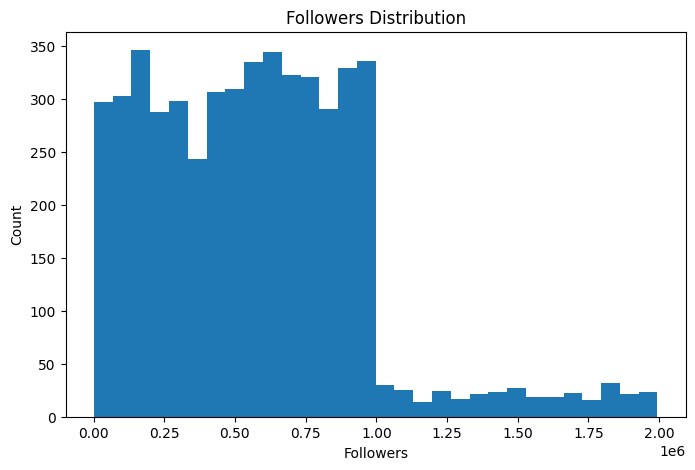

In [8]:
plt.figure(figsize=(8,5))

plt.hist(df['Followers'], bins=30)

plt.title("Followers Distribution")
plt.xlabel("Followers")
plt.ylabel("Count")

plt.show()

### 5.2 Engagement Rate Distribution

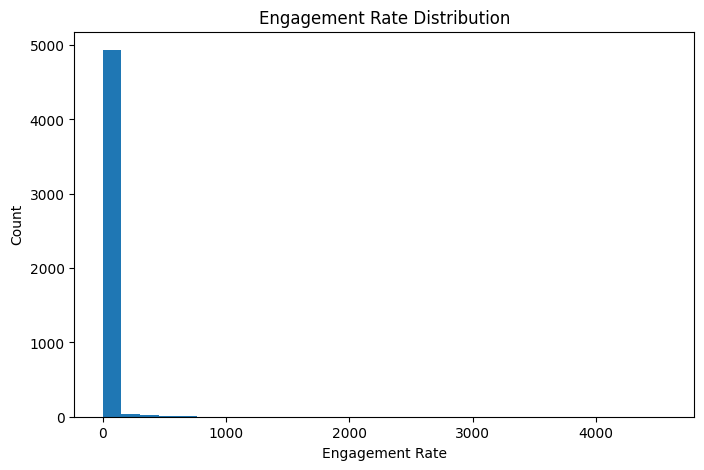

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df['Engagement_Rate'], bins=30)

plt.title("Engagement Rate Distribution")
plt.xlabel("Engagement Rate")
plt.ylabel("Count")

plt.show()

## 6. Feature Selection and Data Scaling

The selected features are standardized before applying anomaly detection algorithms to ensure all variables contribute equally to model performance.

In [10]:
features = [
    'Followers',
    'Following',
    'Posts',
    'Likes_Avg',
    'Comments_Avg',
    'Growth_Rate',
    'Engagement_Rate',
    'Follower_Following_Ratio',
    'Comment_Like_Ratio',
    'Likes_Per_Post',
    'Comments_Per_Post'
]

X = df[features]

X.head()

,Followers,Following,Posts,Likes_Avg,Comments_Avg,Growth_Rate,Engagement_Rate,Follower_Following_Ratio,Comment_Like_Ratio,Likes_Per_Post,Comments_Per_Post
0,122958,1156,1486,6349,3485,12.464957,7.997853,106.365052,0.548905,4.272544,2.345222
1,672155,2274,1748,7880,344,8.573665,1.223527,295.582674,0.043655,4.508009,0.196796
2,132932,247,33,44257,157,11.666187,33.411067,538.186235,0.003547,1341.121212,4.757576
3,366838,2721,965,37620,1426,15.446852,10.643935,134.817347,0.037905,38.984456,1.477720
4,260178,3542,1896,22491,3056,4.358427,9.819047,73.455110,0.135877,11.862342,1.611814


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(5000, 11)


## 7. Isolation Forest Model

Isolation Forest is an unsupervised anomaly detection algorithm that isolates unusual observations and identifies potentially fraudulent influencer profiles.

In [12]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.10,
    random_state=42
)

df['IF_Result'] = iso.fit_predict(X_scaled)

df['IF_Result'].value_counts()

IF_Result
 1    4500
-1     500
Name: count, dtype: int64

## 8. Local Outlier Factor (LOF) Model

Local Outlier Factor is used to identify observations that significantly differ from their local neighborhood. It helps detect influencers with unusual engagement behavior.

In [13]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.10
)

df['LOF_Result'] = lof.fit_predict(X_scaled)

df['LOF_Result'].value_counts()

LOF_Result
 1    4500
-1     500
Name: count, dtype: int64

## 9. Fraud Risk Score Calculation

Fraud risk scores are generated by combining the outputs of Isolation Forest and Local Outlier Factor models.

In [14]:
iso_score = np.where(
    df['IF_Result'] == -1,
    100,
    20
)

lof_score = np.where(
    df['LOF_Result'] == -1,
    100,
    20
)

df['Fraud_Risk_Score'] = (
    iso_score * 0.6 +
    lof_score * 0.4
)

In [15]:
def risk_category(score):

    if score <= 30:
        return "Safe"

    elif score <= 60:
        return "Review"

    elif score <= 80:
        return "Suspicious"

    else:
        return "High Risk"

df['Risk_Category'] = df[
    'Fraud_Risk_Score'
].apply(risk_category)

df['Risk_Category'].value_counts()

Risk_Category
Safe          4355
High Risk      355
Review         145
Suspicious     145
Name: count, dtype: int64

In [16]:
df.to_csv(
    "Influencer_Fraud_Scores.csv",
    index=False
)

print("File Saved Successfully")

File Saved Successfully


## 10. Risk Category Analysis

The fraud risk scores were categorized into four groups: Safe, Review, Suspicious, and High Risk. This categorization helps businesses prioritize influencer verification efforts.

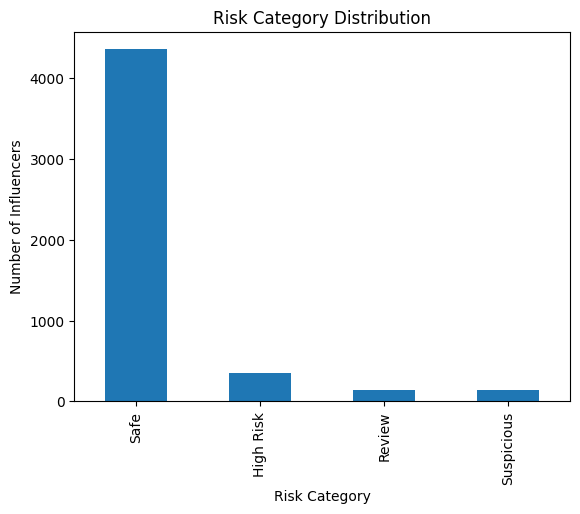

In [17]:
df['Risk_Category'].value_counts().plot(
    kind='bar'
)

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Influencers")

plt.show()

### Risk Category Distribution

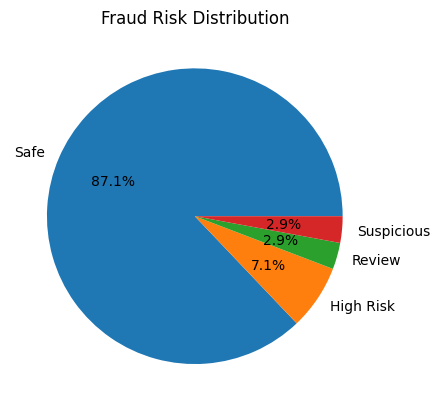

In [18]:
df['Risk_Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel("")

plt.title("Fraud Risk Distribution")

plt.show()

## 11. High-Risk Influencer Profiles

The following profiles have the highest fraud risk scores and may require manual verification.

In [19]:
df.sort_values(
    by='Fraud_Risk_Score',
    ascending=False
).head(10)

,Followers,Following,Posts,Likes_Avg,Comments_Avg,Growth_Rate,Engagement_Rate,Follower_Following_Ratio,Comment_Like_Ratio,Likes_Per_Post,Comments_Per_Post,IF_Result,LOF_Result,Fraud_Risk_Score,Risk_Category
4996,934713,1359,371,787,3698,6.759909,0.479826,687.794702,4.698856,2.121294,9.967655,-1,-1,100.0,High Risk
4938,15743,302,152,23779,489,-1.918843,154.151051,52.129139,0.020564,156.440789,3.217105,-1,-1,100.0,High Risk
4941,243717,3314,1431,69,250,19.425356,0.130890,73.541642,3.623188,0.048218,0.174703,-1,-1,100.0,High Risk
4923,562158,72,531,399,45,-4.937614,0.078981,7807.750000,0.112782,0.751412,0.084746,-1,-1,100.0,High Risk
4930,1159,4466,1685,2877,1930,-3.514926,414.754098,0.259516,0.670838,1.707418,1.145401,-1,-1,100.0,High Risk
4918,507581,1403,56,29423,1676,-0.511403,6.126904,361.782609,0.056962,525.410714,29.928571,-1,-1,100.0,High Risk
4888,457887,647,12,49038,4379,13.221757,11.665979,707.707883,0.089298,4086.500000,364.916667,-1,-1,100.0,High Risk
4873,23031,4136,1140,44000,3899,15.788407,207.976206,5.568424,0.088614,38.596491,3.420175,-1,-1,100.0,High Risk
4875,868239,2258,74,17583,4533,-4.192452,2.547225,384.516829,0.257806,237.608108,61.256757,-1,-1,100.0,High Risk
4862,42869,4966,1495,46165,1423,12.531975,111.007954,8.632501,0.030824,30.879599,0.951839,-1,-1,100.0,High Risk


## 12. Conclusion

This project successfully developed an influencer fraud detection framework using unsupervised machine learning techniques.

Isolation Forest and Local Outlier Factor models were applied to identify suspicious influencer profiles based on engagement metrics and audience interaction patterns.

The generated fraud risk score enables businesses and marketing agencies to prioritize influencer verification and reduce the risk of collaborating with fraudulent accounts.

The proposed solution can be extended using real-time social media APIs and additional behavioral features for improved detection performance.

## 13. Exporting Final Results

The final fraud detection results are exported as a CSV file for further analysis and business decision-making.

In [20]:
df.to_csv(
    "Influencer_Fraud_Scores.csv",
    index=False
)

print("File Saved Successfully")

File Saved Successfully
